# Análise dos testes

### Imports

In [1]:
from os import makedirs
from os.path import join
from json import load, dump

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from nltk import download
from rouge_score.rouge_scorer import RougeScorer
from tqdm.notebook import tqdm

from scripts.test import Test
from scripts.data import SimpleLesionData, SimpleDatasetAnalysis, get_skin_lesions_numeric_labels_dict, get_risk_labels_dict

import scripts.definitions as defs
import scripts.analysis as analysis

### Configuração

In [2]:
TEST_NAME = 'LLaDerm-0.21-11B-4bit_test_2025-04-15T17_51_53.759180.json'

### Carregamento dos testes e dados

In [3]:
with open(join(defs.RESULTS_PATH, 'tests', TEST_NAME), 'r', encoding='utf-8') as file:
    test = Test(**load(file))

with open(join(defs.DATA_PATH, 'stt_data', 'test_dataset.json'), 'r', encoding='utf-8') as file:
    test_dataset = [SimpleLesionData(**data) for data in load(file)]

with open(join(defs.DATA_PATH, 'stt_data', 'training_dataset.json'), 'r', encoding='utf-8') as file:
    training_dataset = [SimpleLesionData(**data) for data in load(file)]

with open(join(defs.DATA_PATH, 'simple_dataset_analysis.json'), 'r', encoding='utf-8') as file:
    simple_dataset_analysis = SimpleDatasetAnalysis(**load(file))

with open(join(defs.DATA_PATH, 'test_dataset_analysis.json'), 'r', encoding='utf-8') as file:
    test_dataset_analysis = SimpleDatasetAnalysis(**load(file))

with open(join(defs.DATA_PATH, 'training_dataset_analysis.json'), 'r', encoding='utf-8') as file:
    training_dataset_analysis = SimpleDatasetAnalysis(**load(file))

### Processamento dos testes

In [4]:
simple_results_on_test = test.results_on_test_data
simple_results_on_training = test.results_on_training_data

structured_classification_results_on_test = analysis.structure_classification_results(test.model.prompt_type, test.results_on_test_data)
structured_classification_results_on_training = analysis.structure_classification_results(test.model.prompt_type, test.results_on_training_data)

### Salvamento dos testes processados

In [5]:
valid_results_on_test = list(filter(lambda x: x.answer.valid, structured_classification_results_on_test))
invalid_results_on_test = list(filter(lambda x: not x.answer.valid, structured_classification_results_on_test))

print(f'Resultados válidos para testes sobre dados de teste: {len(valid_results_on_test)}')
print(f'Resultados inválidos para testes sobre dados de teste: {len(invalid_results_on_test)}')

valid_results_on_training = list(filter(lambda x: x.answer.valid, structured_classification_results_on_training))
invalid_results_on_training = list(filter(lambda x: not x.answer.valid, structured_classification_results_on_training))

print(f'Resultados válidos para testes sobre dados de treinamento: {len(valid_results_on_training)}')
print(f'Resultados inválidos para testes sobre dados de treinamento: {len(invalid_results_on_training)}')

test_analysis = analysis.TestAnalysis(
    test_name=TEST_NAME,
    valid_results_on_test_data=valid_results_on_test,
    valid_results_on_training_data=valid_results_on_training,
    invalid_results_on_test_data=invalid_results_on_test,
    invalid_results_on_training_data=invalid_results_on_training
)

makedirs(join(defs.RESULTS_PATH, 'tests', 'analysis'), exist_ok=True)

with open(join(defs.RESULTS_PATH, 'tests', 'analysis', TEST_NAME.replace('.json', '_analysis.json')), 'w', encoding='utf-8') as file:
    dump(test_analysis.model_dump(), file, indent=4, ensure_ascii=False)

Resultados válidos para testes sobre dados de teste: 1167
Resultados inválidos para testes sobre dados de teste: 0
Resultados válidos para testes sobre dados de treinamento: 0
Resultados inválidos para testes sobre dados de treinamento: 0


### Associação de pares com as respostas corretas

In [6]:
simple_result_pair_on_test = analysis.associate_simple_results_with_data(test_dataset,
                                                                         test.model.prompt_type,
                                                                         simple_results_on_test)

simple_result_pair_on_training = analysis.associate_simple_results_with_data(training_dataset,
                                                                             test.model.prompt_type,
                                                                             simple_results_on_training)

result_pairs_on_test = analysis.associate_classification_results_with_data(test_dataset,
                                                                           test.model.prompt_type,
                                                                           structured_classification_results_on_test)

result_pairs_on_training = analysis.associate_classification_results_with_data(
    training_dataset, test.model.prompt_type, structured_classification_results_on_training)

### Sanitização dos pares

In [7]:
skin_lesion_label_pairs_on_test = analysis.get_label_pairs(result_pairs_on_test, 'skin_lesion')
skin_lesion_label_pairs_on_training = analysis.get_label_pairs(result_pairs_on_training, 'skin_lesion')
risk_label_pairs_on_test = analysis.get_label_pairs(result_pairs_on_test, 'risk')
risk_label_pairs_on_training = analysis.get_label_pairs(result_pairs_on_training, 'risk')

### Conversão das labels de lesões de pele

In [8]:
skin_lesions_numeric_labels_dict = get_skin_lesions_numeric_labels_dict(simple_dataset_analysis)
risk_labels_dict = get_risk_labels_dict(simple_dataset_analysis)

DEFAULT_LABEL = 'I'

numeric_skin_lesion_pairs_on_test = []
numeric_skin_lesion_pairs_on_training = []
risk_pairs_on_test = []
risk_pairs_on_training = []

for pair in skin_lesion_label_pairs_on_test:
    expected = skin_lesions_numeric_labels_dict.get(pair[0], DEFAULT_LABEL)
    predicted = skin_lesions_numeric_labels_dict.get(pair[1], DEFAULT_LABEL)

    numeric_skin_lesion_pairs_on_test.append((expected, predicted))

for pair in risk_label_pairs_on_test:
    expected = risk_labels_dict.get(pair[0], DEFAULT_LABEL)
    predicted = risk_labels_dict.get(pair[1], DEFAULT_LABEL)

    risk_pairs_on_test.append((expected, predicted))

for pair in skin_lesion_label_pairs_on_training:
    expected = skin_lesions_numeric_labels_dict.get(pair[0], DEFAULT_LABEL)
    predicted = skin_lesions_numeric_labels_dict.get(pair[1], DEFAULT_LABEL)

    numeric_skin_lesion_pairs_on_training.append((expected, predicted))

for pair in risk_label_pairs_on_training:
    expected = risk_labels_dict.get(pair[0], DEFAULT_LABEL)
    predicted = risk_labels_dict.get(pair[1], DEFAULT_LABEL)

    risk_pairs_on_training.append((expected, predicted))

### Análise dos testes sobre os dados de teste

Classificação de lesões de pele:
              precision    recall  f1-score   support

           1      0.456     0.470     0.463       198
          10      0.444     0.800     0.571        25
          11      0.000     0.000     0.000        19
          12      0.000     0.000     0.000         9
          13      1.000     0.120     0.214        25
          14      0.267     0.250     0.258        16
          15      0.000     0.000     0.000         5
          16      0.000     0.000     0.000         9
          17      0.077     1.000     0.143         1
          18      0.000     0.000     0.000         6
          19      0.000     0.000     0.000         9
           2      0.552     0.679     0.609       187
          20      0.571     0.308     0.400        13
          21      0.000     0.000     0.000         4
          22      0.200     0.286     0.235         7
          23      0.250     0.600     0.353         5
          24      0.000     0.000     0.000     

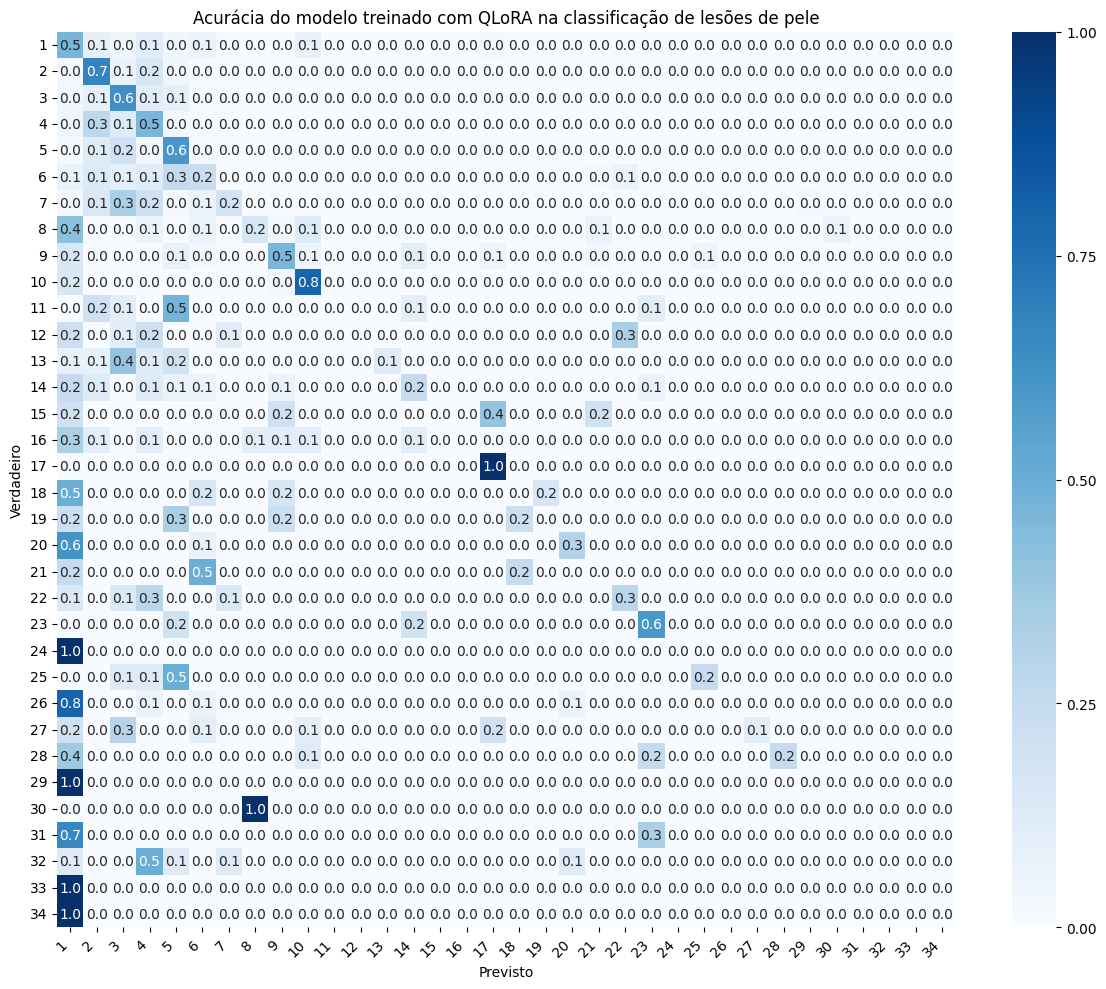

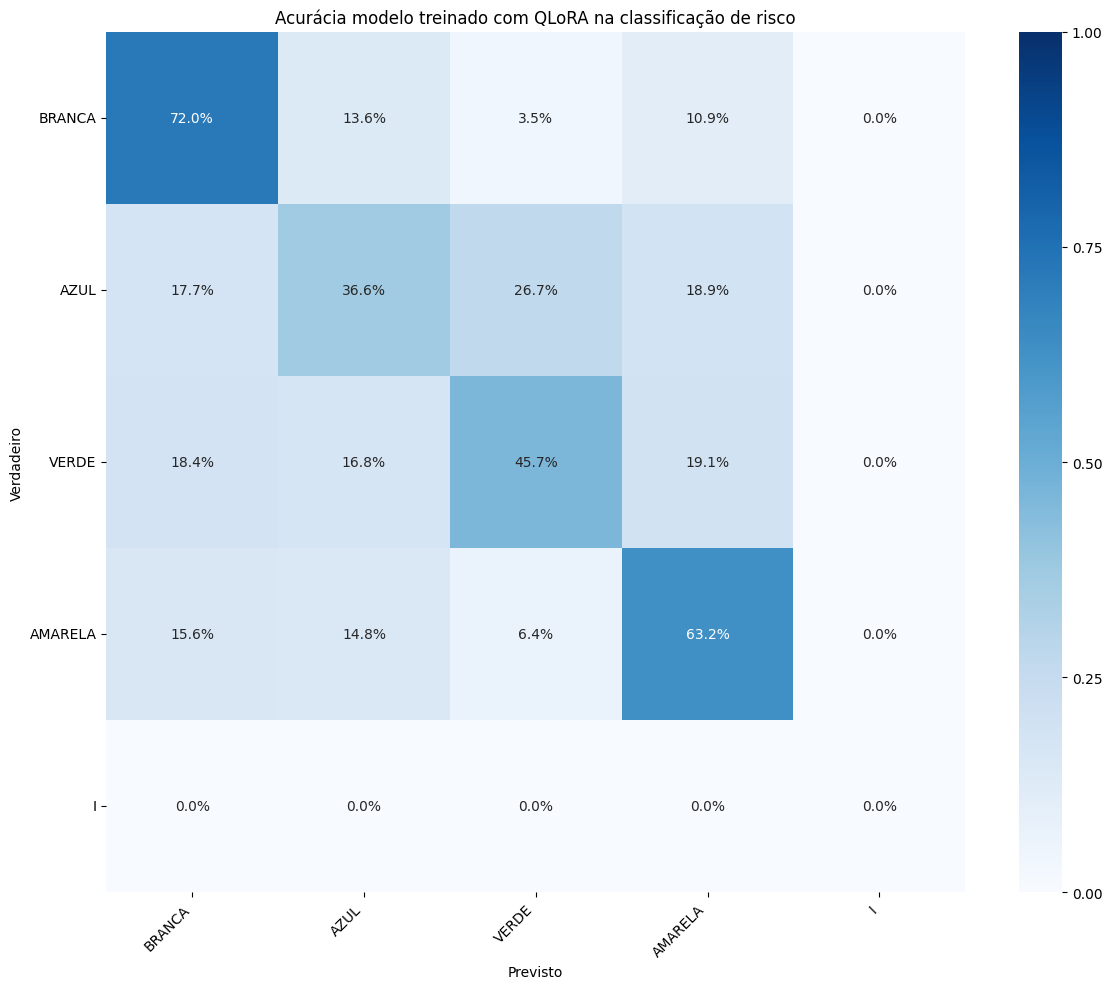

In [9]:
model_name = test.tested_model
quantized = '(Quantizado)' if test.model.quantized else ''

if len(result_pairs_on_test) > 0:
    print('Classificação de lesões de pele:')
    print(analysis.calculate_classification_report(numeric_skin_lesion_pairs_on_test))

    print('Classificação do risco:')
    print(analysis.calculate_classification_report(risk_pairs_on_test))

    skin_lesion_classes = list(map(lambda x: x[1], skin_lesions_numeric_labels_dict.items()))

    if 'I' in list(map(lambda x: x[1], numeric_skin_lesion_pairs_on_test)):
        skin_lesion_classes += [DEFAULT_LABEL]

    analysis.create_confusion_matrix(numeric_skin_lesion_pairs_on_test,  # type: ignore
                                     skin_lesion_classes,
                                     f'Acurácia do modelo treinado com QLoRA na classificação de lesões de pele',
                                     join(defs.RESULTS_PATH, 'plots', f'skin_lesions_{TEST_NAME[:-4]}'),
                                     True,
                                     '.1f')

    if test.model.prompt_type == defs.PromptType.REPORT:
        risk_classes = list(map(lambda x: x[1], risk_labels_dict.items())) + [DEFAULT_LABEL]

        risk_accuracy = analysis.create_confusion_matrix(risk_pairs_on_test,  # type: ignore
                                                         risk_classes,
                                                         f'Acurácia modelo treinado com QLoRA na classificação de risco',
                                                         join(defs.RESULTS_PATH, 'plots', f'risk_{TEST_NAME[:-4]}'))

### Análise dos testes sobre os dados de treinamento

In [ ]:
if len(result_pairs_on_training) > 0:
    print('Classificação de lesões de pele:')
    print(analysis.calculate_classification_report(numeric_skin_lesion_pairs_on_training))

    print('Classificação do risco:')
    print(analysis.calculate_classification_report(risk_pairs_on_training))

    analysis.create_confusion_matrix(numeric_skin_lesion_pairs_on_training,  # type: ignore
                                     skin_lesion_classes,
                                     f'{model_name} {quantized} - Lesões de pele',
                                     join(defs.RESULTS_PATH, 'plots', f'skin_lesions_{TEST_NAME[:-4]}'),
                                     True,
                                     '.1f')

    if test.model.prompt_type == defs.PromptType.REPORT:
        risk_accuracy = analysis.create_confusion_matrix(risk_pairs_on_training,  # type: ignore
                                                         risk_classes,
                                                         f'{model_name} {quantized} - Classificação de risco',
                                                         join(defs.RESULTS_PATH, 'plots', f'risk_{TEST_NAME[:-4]}'))

: 

### Análise estatística dos textos sobre os dados de teste

In [ ]:
download('wordnet')

bleu_scores_1 = []
bleu_scores_2 = []
bleu_scores_3 = []
bleu_scores_4 = []
rouge1_precision = []
rouge1_recall = []
rouge1_fmeasure = []
rougeL_precision = []
rougeL_recall = []
rougeL_fmeasure = []
meteor_scores = []

rouge_scorer = RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

for simple_result_pair in tqdm(simple_result_pair_on_test, desc='Analisando resultados: '):
    expected = simple_result_pair.expected
    answer = simple_result_pair.answer

    bleu_score_1 = sentence_bleu([expected.split()], answer.split(), weights=(1.0, 0.0, 0.0, 0.0))
    bleu_score_2 = sentence_bleu([expected.split()], answer.split(), weights=(0.5, 0.5, 0.0, 0.0))
    bleu_score_3 = sentence_bleu([expected.split()], answer.split(), weights=(0.333, 0.333, 0.333, 0.0))
    bleu_score_4 = sentence_bleu([expected.split()], answer.split(), weights=(0.25, 0.25, 0.25, 0.25))

    bleu_scores_1.append(bleu_score_1)
    bleu_scores_2.append(bleu_score_2)
    bleu_scores_3.append(bleu_score_3)
    bleu_scores_4.append(bleu_score_4)

    rouge_scores = rouge_scorer.score(expected, answer)

    precision, recall, fmeasure = rouge_scores['rouge1']

    rouge1_precision.append(precision)
    rouge1_recall.append(recall)
    rouge1_fmeasure.append(fmeasure)

    precision, recall, fmeasure = rouge_scores['rougeL']

    rougeL_precision.append(precision)
    rougeL_recall.append(recall)
    rougeL_fmeasure.append(fmeasure)

    meteor_score_value = meteor_score([expected.split()], answer.split())

    meteor_scores.append(meteor_score_value)


print(f'BLEU-1: {sum(bleu_scores_1) / len(bleu_scores_1):.3f}')
print(f'BLEU-2: {sum(bleu_scores_2) / len(bleu_scores_2):.3f}')
print(f'BLEU-3: {sum(bleu_scores_3) / len(bleu_scores_3):.3f}')
print(f'BLEU-4: {sum(bleu_scores_4) / len(bleu_scores_4):.3f}')
print(f'ROUGE-1 precision: {sum(rouge1_precision) / len(rouge1_precision):.3f}')
print(f'ROUGE-1 recall: {sum(rouge1_recall) / len(rouge1_recall):.3f}')
print(f'ROUGE-1 fmeasure: {sum(rouge1_fmeasure) / len(rouge1_fmeasure):.3f}')
print(f'ROUGE-L precision: {sum(rougeL_precision) / len(rougeL_precision):.3f}')
print(f'ROUGE-L recall: {sum(rougeL_recall) / len(rougeL_recall):.3f}')
print(f'ROUGE-L fmeasure: {sum(rougeL_fmeasure) / len(rougeL_fmeasure):.3f}')
print(f'METEOR: {sum(meteor_scores) / len(meteor_scores):.3f}')

[nltk_data] Downloading package wordnet to /home/erfer/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Analisando resultados:   0%|          | 0/1167 [00:00<?, ?it/s]

BLEU-1: 0.551
BLEU-2: 0.524
BLEU-3: 0.511
BLEU-4: 0.500
ROUGE-1 precision: 0.714
ROUGE-1 recall: 0.678
ROUGE-1 fmeasure: 0.643
ROUGE-L precision: 0.659
ROUGE-L recall: 0.629
ROUGE-L fmeasure: 0.604
METEOR: 0.580


: 